This page aims to reproduce the Numerical Experiment from Section 4 of Margossian et al. Some of the plotting code is from analyze_results.ipynb    

We know several things:
1. some of the functions that was used in Dr. M's repo belongs to 'utility.py' script, and it is not publicly accessible (yet), therefore we might not be able to know how exactly the sq.err is calculted
2.

In [3]:
!pip install -Uq tfp-nightly[jax]
!pip install inference_gym
!pip install tf-nightly

# remember to restart runtime after changing the environment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.1/622.1 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 29.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1

In [1]:
import numpy as np
# from matplotlib.pyplot import *

import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
from jax import random
from jax import numpy as jnp

# from inference_gym import using_jax as gym

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
from inference_gym import using_jax as gym
tfb = tfp.bijectors

from tensorflow_probability.substrates import numpy as tfp_np
tfd_np = tfp_np.distributions

import matplotlib.pyplot as plt

import pandas as pd

import gc

# check if this is run on a gpu
print(jax.devices())
print(jax.default_backend())

import warnings
warnings.filterwarnings('ignore')

import psutil

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

[CudaDevice(id=0)]
gpu


below is tying to replicate section 4.2:  
results when running 2048 chains with K =16 superchains, M = 128 subchains per superchains, after warmup, we do N=1 sample. For every model we repeat the experiment 10 times. each time we use different seed and run the experiements, we need to keep all 10 results, plot the avg MSE, best run and the worst run.  
The warmup window are:[  10   20   30   40   50   60   70   80   90  100  200  300  400  500
  600  700  800  900 1000]



Set up the problem, so far we dont change the number of superchain/subchains:

In [2]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

print(warmup_length)

[  10   20   30   40   50   60   70   80   90  100  200  300  400  500
  600  700  800  900 1000]


In [3]:
# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

def kernel_setup(warmup_length, naive):
  num_warmup_short, num_sampling_short = warmup_length, 1
  total_samples_short = num_warmup_short + num_sampling_short

  kernel_short = tfp.mcmc.HamiltonianMonteCarlo(target_log_prob_fn, init_step_size, 1)
  kernel_short = tfp.experimental.mcmc.GradientBasedTrajectoryLengthAdaptation(kernel_short, num_warmup_short)
  kernel_short = tfp.mcmc.DualAveragingStepSizeAdaptation(
      kernel_short, num_warmup_short, target_accept_prob = 0.75,  #0.75,
      reduce_fn = tfp.math.reduce_log_harmonic_mean_exp)

  if (naive):
    # initialize each chain at a different location, could it be the naive way?
    # it might actually be!
    initial_state = initialize((num_chains_short,))

  else:
    # Chains within a super chain are all initialized at the same location
    # Here we use the same initial points as in the long regime.
    initial_state = initialize((num_super_chains,))
    initial_state = np.repeat(initial_state, num_chains_short // num_super_chains,
                            axis = 0)
  return kernel_short, initial_state, total_samples_short

def _reduce_variance_interval(x, axis=None, biased=True, keepdims=False):
    # ddof=0 is biased variance (N), ddof=1 is unbiased variance (N-1)
    ddof = 0 if biased else 1
    return jnp.var(x, axis=axis, ddof=ddof, keepdims=keepdims)


def nested_rhat_constrained(result_state, num_super_chains,idx):
    # since we use only N=1, W_k is reduced to 0

    num_sub_chains = result_state.shape[0] // num_super_chains
    num_dimensions = result_state.shape[1]

    chain_states = result_state.reshape(1, -1, num_sub_chains, num_dimensions)
    # chain_states.shape = (1,16,128,2)
    # f_bar 1*k is:
    mean_subchain = jnp.mean(chain_states, axis=2)
    # mean_subchain.shape =(1,16,2)

    # f_bar **K is:
    mean_superchain = jnp.mean(mean_subchain, axis=1)
    # mean_superchain.shape = (1,2)

    variance_chain = _reduce_variance_interval(chain_states, axis=2, biased=False)
    # print(variance_chain.shape) # (1,16,2)
    W = jnp.mean(variance_chain, axis=1)
    # print(f"W dim: {W.shape}") # (1,2)
    B = _reduce_variance_interval(mean_subchain, axis=1, biased=False) # variance of between super chain

    r_hat = jnp.sqrt(1+B/W)[:,idx]
    return r_hat

In [4]:
def simulation(keys,length, naive, repitition, MSE_list, R_Hat_list, num_dim):
  kernel_short, initial_state, total_samples_short = kernel_setup(length,naive)
  result_mse = []
  for sim in range(repitition):
    result_short = tfp.mcmc.sample_chain(
        total_samples_short, initial_state, kernel = kernel_short,
        seed =keys[sim], trace_fn=None)[-1,:,:]

    # the f bar
    estimate = result_short.mean(axis=0)
    error = estimate - mean_est
    se = error**2
    # following the formula from paper, there is a factor = KM/var
    # when doing KM/var, the MSE jumps to 10^3, which is what was in the plot.
    factor = 1/var_est
    mse = (factor * se).mean()
    result_mse.append(mse)

    record = {
        "Warmup Length": length,
        "MSE":mse,
    }

    for dim in range(num_dim):
      new_r_hat = nested_rhat_constrained(result_short, num_super_chains, dim)
      record[f"r_hat_{dim}"] = new_r_hat[-1]
    R_Hat_list.append(record)
    del record
    del result_short
    gc.collect()

  # calculation time:
  result_mse = np.array(result_mse)
  result_mse_best = result_mse.min(axis=0)
  result_mse_worst = result_mse.max(axis=0)
  estimate_mse = result_mse.mean(axis=0)

  MSE_list.append({"Warmup Length":length,
                   "Avg MSE": estimate_mse,
                   "Best MSE": result_mse_best,
                   "Worst MSE": result_mse_worst})
  if naive:
    print(f"Naive initialization. Warmup Length: {length}; mean of MSE is: {estimate_mse}")
  else:
    print(f"Constrained initialization. Warmup Length: {length}; mean of MSE is: {estimate_mse}")
  del kernel_short
  del initial_state
  del total_samples_short
  del result_mse
  gc.collect()
  jax.clear_caches()

In [5]:
from matplotlib.lines import Line2D

def MSE_vs_Warmup(constrained_df, naive_df, title):
  ax = constrained_df.plot(
    x="Warmup Length",
    y="Avg MSE",
    logx=True,
    logy=True,
    title=title,
    linestyle="-",
    color="orange",
    legend=False
  )
  constrained_df.plot(
    x="Warmup Length",
    y="Best MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="orange",
    legend=False,
    ax=ax)
  constrained_df.plot(
    x="Warmup Length",
    y="Worst MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="orange",
    legend=False,
    ax=ax)
  naive_df.plot(
    x="Warmup Length",
    y="Avg MSE",
    logx=True,
    logy=True,
    linestyle="-",
    color="black",
    legend=False,
    ax=ax)
  naive_df.plot(
    x="Warmup Length",
    y="Worst MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="black",
    legend=False,
    ax=ax)
  naive_df.plot(
    x="Warmup Length",
    y="Best MSE",
    logx=True,
    logy=True,
    linestyle="--",
    color="black",
    legend=False,
    ax=ax)
  ax.legend(handles=[
    Line2D([0], [0], color="orange", lw=2, label="Constrained"),
    Line2D([0], [0], color="black", lw=2, label="Naive")])

In [6]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1

from copy import deepcopy

def MSE_vs_Rhat(constrained_df, naive_df, title, naive):
    constrained_df_copy = deepcopy(constrained_df)
    naive_df_copy = deepcopy(naive_df)

    # Shift all r_hat columns by 1
    for df in [constrained_df_copy, naive_df_copy]:
        rhat_cols = [c for c in df.columns if c.startswith("r_hat_")]
        df[rhat_cols] = df[rhat_cols] - 1

    if naive:
        df = naive_df_copy
    else:
        df = constrained_df_copy

    rhat_cols = [c for c in df.columns if c.startswith("r_hat_")]

    # Plot the first column to create the axes
    ax = df.plot.scatter(
        x=rhat_cols[0],
        y="MSE",
        logy=True,
        logx=not naive,
        title=title,
    )

    # Overlay the remaining columns
    for col in rhat_cols[1:]:
        df.plot.scatter(
            x=col,
            y="MSE",
            logy=True,
            logx=not naive,
            ax=ax,
        )

    ax.axhline(y=chi_up / num_chains_short, color='black', linestyle='--')
    ax.axhline(y=chi_lo / num_chains_short, color='black', linestyle='--')
    ax.axhline(y=1 / num_chains_short, color='black')
    ax.axvline(x=eps_lower, linestyle='--', color='blue')
    ax.set_xlabel(r"$\widehat{R}_{\nu} - 1$")

**Rosenbrock Example**

In [5]:
target = gym.targets.VectorModel(gym.targets.Banana(),
                                 flatten_sample_transformations=True)
num_dimensions = target.event_shape[0]
init_step_size = 1.

def target_log_prob_fn(x):
  """Unnormalized, unconstrained target density.

  This is a thin wrapper that applies the default bijectors so that we can
  ignore any constraints.
  """
  y = target.default_event_space_bijector(x)
  fldj = target.default_event_space_bijector.forward_log_det_jacobian(x)
  return target.unnormalized_log_prob(y) + fldj

# NOTE: Avoid initials centered around the true mean.
offset = 2
def initialize (shape, key = random.PRNGKey(37272709)):
  return 10 * random.normal(key, shape + (num_dimensions,)) + offset

In [6]:
# Get some estimates of the mean and variance.
try:
  mean_est = target.sample_transformations['identity'].ground_truth_mean
except:
  print('no ground truth mean')
  mean_est = (result.all_states[num_warmup:, :]).mean(0).mean(0)
try:
  var_est = target.sample_transformations['identity'].ground_truth_standard_deviation**2
except:
  print('no ground truth std dev')
  var_est = ((result.all_states[num_warmup:, :]**2).mean(0).mean(0) -
             mean_est**2)

In [7]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

#simulation part:
MSE_constrained_list = []
MSE_naive_list = []
R_Hat_constrained_list = []
R_Hat_naive_list = []


for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,
            length,
            naive=False,
            repitition=repitition,
            MSE_list=MSE_constrained_list,
            R_Hat_list=R_Hat_constrained_list,
            num_dim =num_dimensions)
  simulation(
            keys,
            length,
            naive=True,
            repitition=repitition,
            MSE_list=MSE_naive_list,
            R_Hat_list=R_Hat_naive_list,
            num_dim =num_dimensions)


MSE_constrained_df = pd.DataFrame(MSE_constrained_list)
MSE_naive_df = pd.DataFrame(MSE_naive_list)

R_Hat_constrained_df = pd.DataFrame(R_Hat_constrained_list)
R_Hat_naive_df = pd.DataFrame(R_Hat_naive_list)
# '''
# Warmup Length: 10; mean of MSE is: 0.20054090023040771
# Warmup Length: 10; mean of MSE is: 0.15985234081745148
# Warmup Length: 20; mean of MSE is: 0.169586181640625
# Warmup Length: 20; mean of MSE is: 0.13917973637580872
# Warmup Length: 30; mean of MSE is: 0.12024945020675659
# Warmup Length: 30; mean of MSE is: 0.10739566385746002
# Warmup Length: 40; mean of MSE is: 0.08468963205814362
# Warmup Length: 40; mean of MSE is: 0.08053326606750488
# Warmup Length: 50; mean of MSE is: 0.04989621788263321
# Warmup Length: 50; mean of MSE is: 0.05393146350979805
# Warmup Length: 60; mean of MSE is: 0.020449630916118622
# Warmup Length: 60; mean of MSE is: 0.027605745941400528
# Warmup Length: 70; mean of MSE is: 0.007953127846121788
# Warmup Length: 70; mean of MSE is: 0.01065116561949253
# Warmup Length: 80; mean of MSE is: 0.00487165292724967
# Warmup Length: 80; mean of MSE is: 0.004697045776993036
# Warmup Length: 90; mean of MSE is: 0.0025034828577190638
# Warmup Length: 90; mean of MSE is: 0.0012675145408138633
# Warmup Length: 100; mean of MSE is: 0.002771453931927681
# Warmup Length: 100; mean of MSE is: 0.0006108297384344041
# Warmup Length: 200; mean of MSE is: 0.007630533073097467
# Warmup Length: 200; mean of MSE is: 0.00047001655912026763
# Warmup Length: 300; mean of MSE is: 0.003009079722687602
# Warmup Length: 300; mean of MSE is: 0.00045207966468296945
# Warmup Length: 400; mean of MSE is: 0.003978265915066004
# Warmup Length: 400; mean of MSE is: 0.0002966657339129597
# Warmup Length: 500; mean of MSE is: 0.0038260887376964092
# Warmup Length: 500; mean of MSE is: 0.0004999245284125209
# Warmup Length: 600; mean of MSE is: 0.0033442240674048662
# Warmup Length: 600; mean of MSE is: 0.0006521604955196381
# Warmup Length: 700; mean of MSE is: 0.004045634064823389
# Warmup Length: 700; mean of MSE is: 0.0007459042826667428
# Warmup Length: 800; mean of MSE is: 0.002109469147399068
# Warmup Length: 800; mean of MSE is: 0.00043812586227431893
# Warmup Length: 900; mean of MSE is: 0.005968737415969372
# Warmup Length: 900; mean of MSE is: 0.0005841086385771632
# Warmup Length: 1000; mean of MSE is: 0.0024648630060255527
# Warmup Length: 1000; mean of MSE is: 0.00038985570427030325
# '''

Simulation start: 1450.4 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.023071225732564926
Naive initialization. Warmup Length: 10; mean of MSE is: 0.013832764700055122
Simulation start: 1773.6 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.020940138027071953
Naive initialization. Warmup Length: 20; mean of MSE is: 0.013129356317222118
Simulation start: 1773.9 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.01859641633927822
Naive initialization. Warmup Length: 30; mean of MSE is: 0.012206284329295158
Simulation start: 1774.1 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.017247257754206657
Naive initialization. Warmup Length: 40; mean of MSE is: 0.011998618021607399
Simulation start: 1774.1 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.01572386361658573
Naive initialization. Warmup Length: 50; mean of MSE is: 0.011596720665693283
Simulation start: 1774.2 MB
Constrained initializati

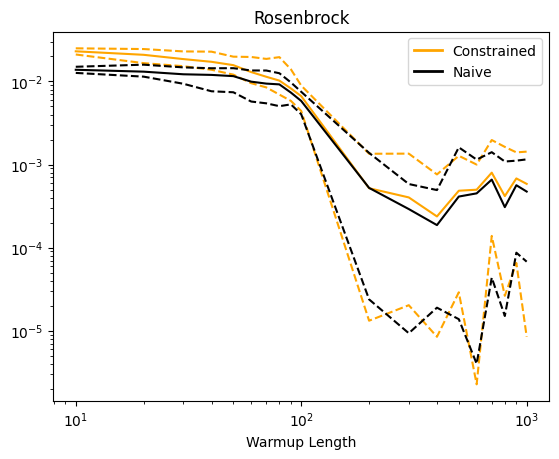

In [9]:
MSE_vs_Warmup(MSE_constrained_df, MSE_naive_df,"Rosenbrock")

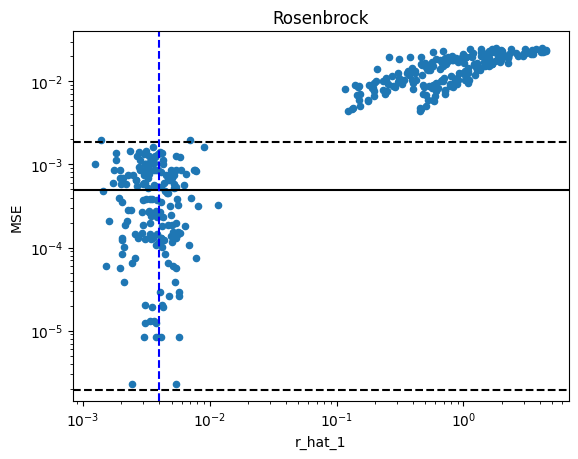

In [19]:
MSE_vs_Rhat(R_Hat_constrained_df, R_Hat_naive_df, "Rosenbrock", naive=False)

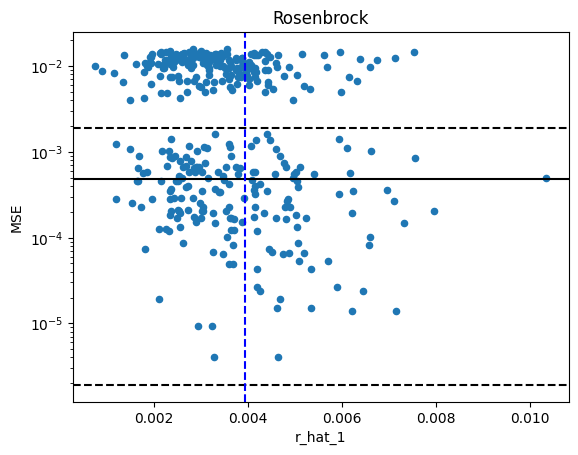

In [20]:
MSE_vs_Rhat(R_Hat_constrained_df, R_Hat_naive_df, "Rosenbrock", naive=True)

Next step:  
repeat this process with bimodal gaussian mixture distribution with:  
100 dimentions, sampled from 0.3*MVN(-mu, I)+0.7MVN(mu,I), where mu is 100 dimentional vector of 5's and I is identity matrix

**Bimodal Example**

In [7]:
num_dimensions = 100
dist = tfd.MixtureSameFamily(
    mixture_distribution=tfd.Categorical(probs=[0.3, 0.7]),
    components_distribution=tfd.MultivariateNormalDiag(
      loc=[jnp.repeat(-5., num_dimensions), jnp.repeat(5., num_dimensions)],
      scale_diag=jnp.repeat(1., num_dimensions)))

def target_log_prob_fn(x):
  return dist.log_prob(x)

offset = 0
def initialize (shape, key = random.PRNGKey(37272709)):
  return 10 * random.normal(key, shape + (num_dimensions,)) + offset

mean_est = jnp.repeat(2, num_dimensions)
var_est = jnp.repeat(22, num_dimensions)

init_step_size = 1

In [8]:
#simulation part:

base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

Bimodal_MSE_constrained_list = []
Bimodal_MSE_naive_list = []
Bimodal_R_Hat_constrained_list = []
Bimodal_R_Hat_naive_list = []


for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,
            length,
            naive=False,
            repitition=repitition,
            MSE_list=Bimodal_MSE_constrained_list,
            R_Hat_list=Bimodal_R_Hat_constrained_list,
            num_dim =num_dimensions)
  simulation(
            keys,
            length,
            naive=True,
            repitition=repitition,
            MSE_list=Bimodal_MSE_naive_list,
            R_Hat_list=Bimodal_R_Hat_naive_list,
            num_dim =num_dimensions)


Bimodal_MSE_constrained_df = pd.DataFrame(Bimodal_MSE_constrained_list)
Bimodal_MSE_naive_df = pd.DataFrame(Bimodal_MSE_naive_list)

Bimodal_R_Hat_constrained_df = pd.DataFrame(Bimodal_R_Hat_constrained_list)
Bimodal_R_Hat_naive_df = pd.DataFrame(Bimodal_R_Hat_naive_list)

Simulation start: 1332.1 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.3117368817329407
Naive initialization. Warmup Length: 10; mean of MSE is: 0.18812508881092072
Simulation start: 1822.4 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.31284818053245544
Naive initialization. Warmup Length: 20; mean of MSE is: 0.18789127469062805
Simulation start: 1822.7 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.31301113963127136
Naive initialization. Warmup Length: 30; mean of MSE is: 0.18793919682502747
Simulation start: 1827.8 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.3133334815502167
Naive initialization. Warmup Length: 40; mean of MSE is: 0.1881648451089859
Simulation start: 1840.1 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.31335216760635376
Naive initialization. Warmup Length: 50; mean of MSE is: 0.18816404044628143
Simulation start: 1849.4 MB
Constrained initialization. Warmup 

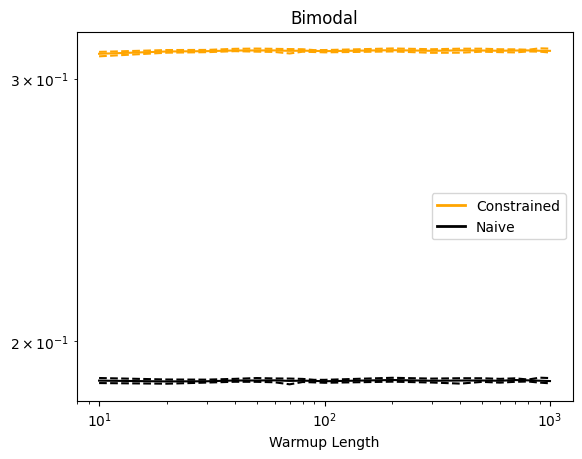

In [9]:
MSE_vs_Warmup(Bimodal_MSE_constrained_df, Bimodal_MSE_naive_df,"Bimodal")

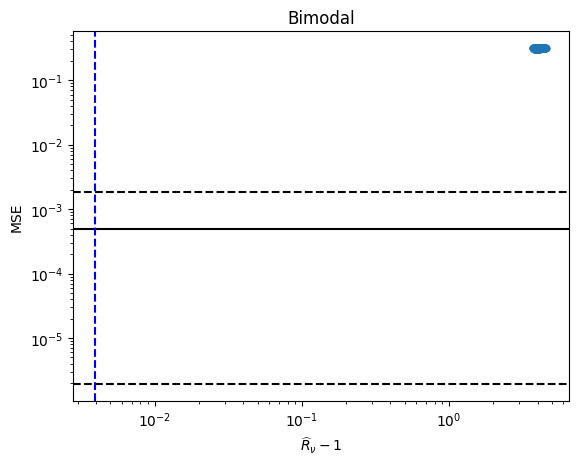

In [10]:
MSE_vs_Rhat(Bimodal_R_Hat_constrained_df, Bimodal_R_Hat_naive_df, "Bimodal", naive=False)

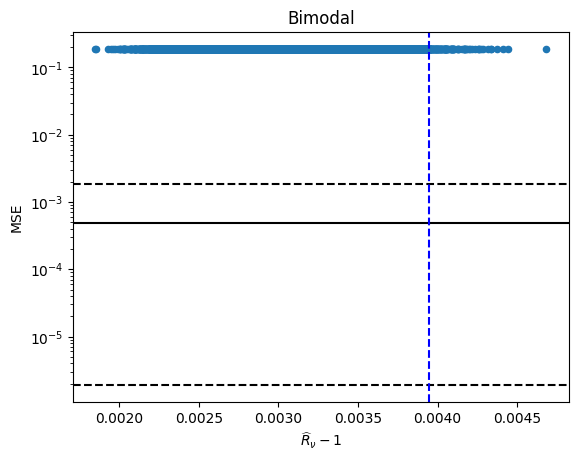

In [11]:
MSE_vs_Rhat(Bimodal_R_Hat_constrained_df, Bimodal_R_Hat_naive_df, "Bimodal", naive=True)

Perhaps we can try other distributions...?  
German Credit Score requires some weird package thing, Item Response Theory requires a ton of memory prior to sampling phase. PK requires some other package.  

Let's try the eight school thing

**Eight School Example**

In [8]:
# NOTE: inference gym stores the centered parameterization
target_raw = gym.targets.EightSchools()  # store raw to examine doc.
target = gym.targets.VectorModel(target_raw,
                                  flatten_sample_transformations = True)
num_dimensions = target.event_shape[0]
init_step_size = 1

# Using underdispersed initis can show case problems with our diagnostics.
# underdispered = False
# Options: underdispersed, overdispersed, prior
init_type = "prior"
if init_type == "underdispersed":
  offset = 0.0
  def initialize (shape, key = random.PRNGKey(37272709)):
    return 1 * random.normal(key, shape + (num_dimensions,)) + offset
elif init_type == "overdispersed":
  offset = 0.0
  def initialize (shape, key = random.PRNGKey(37272709)):
    return 100 * random.normal(key, shape + (num_dimensions,)) + offset
elif init_type == "prior":
  def initialize (shape, key = random.PRNGKey(37272709)):
    prior_scale = jnp.append(jnp.array([10., 1.]), jnp.repeat(1., 8))
    prior_offset = jnp.append(jnp.array([0., 5.]), jnp.repeat(0., 8))
    return prior_scale * random.normal(key, shape + (num_dimensions,)) + prior_offset

In [9]:
num_schools = 8
y = np.array([28, 8, -3, 7, -1, 1, 18, 12], dtype = np.float32)
sigma = np.array([15, 10, 16, 11, 9, 11, 10, 18], dtype = np.float32)

# NOTE: the reinterpreted batch dimension specifies the dimension of
# each indepdent variable, here the school.
model = tfd.JointDistributionSequential([
    tfd.Normal(loc = 0., scale = 10., name = "mu"),
    tfd.Normal(loc = 5., scale = 1., name = "log_tau"),
    tfd.Independent(tfd.Normal(loc = jnp.zeros(num_schools),
                               scale = jnp.ones(num_schools),
                               name = "eta"),
                    reinterpreted_batch_ndims = 1),
    lambda eta, log_tau, mu: (
        tfd.Independent(tfd.Normal(loc = (mu[..., jnp.newaxis] +
                                        jnp.exp(log_tau[..., jnp.newaxis]) *
                                        eta),
                                   scale = sigma),
                        name = "y",
                        reinterpreted_batch_ndims = 1))
  ])

def target_log_prob_fn(x):
  mu = x[:, 0]
  log_tau = x[:, 1]
  eta = x[:, 2:10]
  return model.log_prob((mu, log_tau, eta, y))

In [10]:
# Use results from running 128 chains with 1000 + 5000 iterations each,
# for non-centered parameterization.
mean_est = np.array([5.8006573 ,  2.4502006 ,  0.6532423 ,  0.09639207,
             -0.23725411,  0.04723661, -0.33556408, -0.19666635,
              0.5390533 ,  0.14633301])

var_est = np.array([29.60382   ,  0.26338503,  0.6383733 ,  0.4928926 ,
              0.65307987,  0.52441144,  0.46658015,  0.5248887 ,
              0.49544162,  0.690975])

In [11]:
#simulation part:

base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

School_MSE_constrained_list = []
School_MSE_naive_list = []
School_R_Hat_constrained_list = []
School_R_Hat_naive_list = []


for length in warmup_length:
  simulation(
            keys,
            length,
            naive=False,
            repitition=repitition,
            MSE_list=School_MSE_constrained_list,
            R_Hat_list=School_R_Hat_constrained_list,
            num_dim =num_dimensions)
  simulation(
            keys,
            length,
            naive=True,
            repitition=repitition,
            MSE_list=School_MSE_naive_list,
            R_Hat_list=School_R_Hat_naive_list,
            num_dim =num_dimensions)


School_MSE_constrained_df = pd.DataFrame(School_MSE_constrained_list)
School_MSE_naive_df = pd.DataFrame(School_MSE_naive_list)

School_R_Hat_constrained_df = pd.DataFrame(School_R_Hat_constrained_list)
School_R_Hat_naive_df = pd.DataFrame(School_R_Hat_naive_list)

Constrained initialization. Warmup Length: 10; mean of MSE is: 0.5695723295211792
Naive initialization. Warmup Length: 10; mean of MSE is: 5.836733341217041
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.19184666872024536
Naive initialization. Warmup Length: 20; mean of MSE is: 0.12111122906208038
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.176697239279747
Naive initialization. Warmup Length: 30; mean of MSE is: 0.11951129138469696
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.1607344001531601
Naive initialization. Warmup Length: 40; mean of MSE is: 0.10847799479961395
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.14393603801727295
Naive initialization. Warmup Length: 50; mean of MSE is: 0.09664006531238556
Constrained initialization. Warmup Length: 60; mean of MSE is: 0.12812969088554382
Naive initialization. Warmup Length: 60; mean of MSE is: 0.08479006588459015
Constrained initialization. Warmup Length: 70;

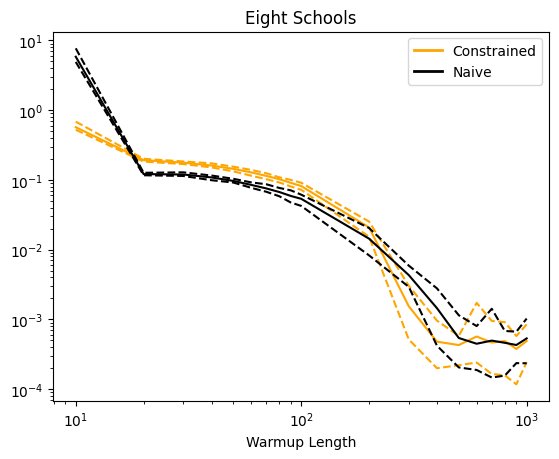

In [13]:
MSE_vs_Warmup(School_MSE_constrained_df, School_MSE_naive_df,"Eight Schools")


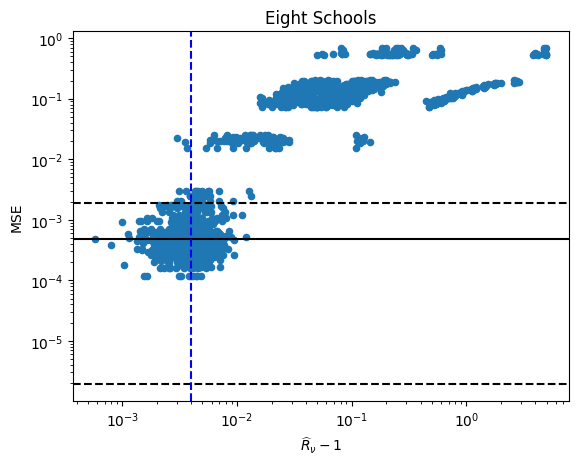

In [20]:
MSE_vs_Rhat(School_R_Hat_constrained_df, School_R_Hat_naive_df, "Eight Schools", naive=False)

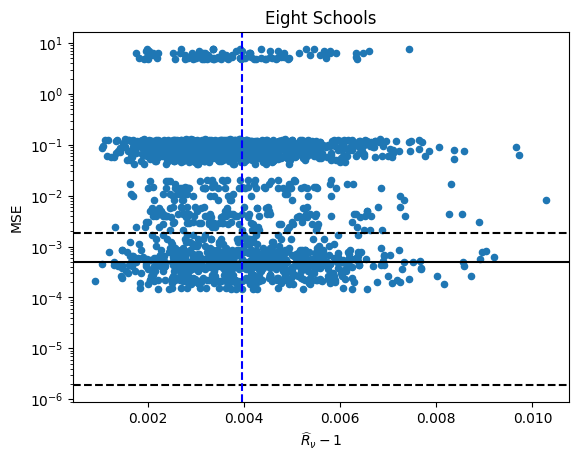

In [19]:
MSE_vs_Rhat(School_R_Hat_constrained_df, School_R_Hat_naive_df, "Eight Schools", naive=True)